### Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from pathlib import Path
import sys
import os

In [17]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

### 1. Data

In [18]:
filepath = os.path.join(grandparent_dir,"ProcessedData/preprocessed_data_final.csv")

In [ ]:
df = pd.read_csv(filepath)
cols = ["Freq","VHr1","Modulation","I1 Mag (A * 10^6)","I2 Mag (A * 10^6)","I3 Mag (A * 10^6)","Rank","File Number"]
df = df[cols]
df1 = df[(df["Rank"] == 6) & (df["File Number"] == 1)] #0.3 Hz, Run 1
df2 = df[(df["Rank"] == 6) & (df["File Number"] == 2)] #0.3 Hz, Run 2
df1

,Freq,VHr1,Modulation,I1 Mag (A * 10^6),I2 Mag (A * 10^6),I3 Mag (A * 10^6),Rank,File Number
5,0.300481,0.001,1mV,0.897473,0.000573,0.000716,6,1
29,0.300481,0.005,5mV,4.465663,0.019968,0.010003,6,1
53,0.300481,0.010,10mV,8.776049,0.072283,0.087238,6,1
77,0.300481,0.020,20mV,16.685291,0.246102,0.646453,6,1
101,0.300481,0.050,50mV,31.826227,0.710037,5.634701,6,1
125,0.300481,0.100,100mV,40.324349,0.642656,14.339171,6,1


### 2. Plots

In [ ]:
def plot_filled_pair(df1, num_currents, point_pairs,run):
    '''
    Plots harmonic growth models based on the starting/ending index of the potential modulations
    to be included in the fit from the dataframe 
    (e.g. 1 mV to 5 mV)
    
    Args:
        df (pd.DataFrame): pandas Dataframe containing the current and voltages of the wanted harmonics
        num_currents (int): number of harmonic currents to be plotted up to, starting from the first harmonic
        points_pairs (tuple): the (start_index, end_index) indices corresponding to the modulations 
        which appear in the dataset when sorted from smallest to largest, starting from 1
        (e.g. 1 mV, 5 mV, 10 mV, ... with corresponding indices of 1, 2, 3)
        run (int): file number 1 or 2
    
    Return:
        None
    '''
    
    # Create Figure
    fig, ax = plt.subplots(figsize=(9, 6.5))
    
    #Initialize Variables
    log_cols = [f"I{x} Mag (A * 10^6)" for x in range(1, num_currents + 1)]
    freq = df1["Freq"].iloc[0]
    f = 96485 / 8.314 / 298
    x_lim_min = 8e-4
    x_lim_max = 1.25e-1
    y_lim_min = 5e-10 * 1e6
    y_lim_max = 5e-4 * 1e6
    triangle_centers_pct = [0.15,0.735,0.42]  # list to store center x of each triangle
    triangle_width_log = 0.12  # width in log10(x) space
    colors = [
    '#318DD9', '#A8C9F4',  # first harmonic: original + pastel
    '#FAA628', '#FFE0A3',  # second harmonic: original + pastel
    '#A000C5', '#D9A3E6',  # third harmonic: original + pastel
    '#00C556', '#99E6B8',  # fourth harmonic: original + pastel
    ]

    # Compute the two-point best fits / Plot the Harmonic Models
    for i, col in enumerate(log_cols):
        slope = i + 1
        idx1, idx2 = point_pairs[i]
        idx1 -= 1  # convert to 0-based
        idx2 -= 1

        # Get x and y values of the two points for line fit
        x_fit = df1['VHr1'].iloc[[idx1, idx2]].values
        y_fit = df1[col].iloc[[idx1, idx2]].values

        # Compute best-fit intercept in log-log space
        X = np.log10(x_fit)
        Y = np.log10(y_fit)
        b = np.mean(Y - slope * X)

        # Generate line for plotting
        x_vals = np.linspace(x_lim_min, x_lim_max, 200)
        y_vals = 10**b * x_vals**slope

        # Color pair
        start = 2 * i
        end = 2 * i + 2
        pair = colors[start:end]
        
        # Plot fit line
        ax.plot(x_vals, y_vals, linestyle='-', color=pair[0], linewidth=2)
        
        #Plot Triangles
        pct = triangle_centers_pct[i]
        x_center = x_lim_min * (x_lim_max/x_lim_min)**pct  # log-scale interpolation
        log_center = np.log10(x_center)
        log_left = log_center - triangle_width_log/2
        log_right = log_center + triangle_width_log/2
        x_left = 10**log_left
        x_right = 10**log_right
        y_base = 10**b * x_left**slope
        y_top = 10**b * x_right**slope
        verts = [(x_left, y_base), (x_right, y_base), (x_right, y_top)]
        triangle = Polygon(verts, closed=True, facecolor=pair[1],edgecolor = pair[0], alpha=1,linewidth=2)
        ax.add_patch(triangle)

        #Plot the Triangle Slope Labels
        x_offset_log = -0.065  # shift right by 0.02 in log10(x)
        y_offset_log = -0.1  # shift down by 0.05 in log10(y)
        x_br = x_right
        y_br = y_base
        x_text = 10**(np.log10(x_br) + x_offset_log)
        y_text = 10**(np.log10(y_br) + y_offset_log)
        ax.text(x_text, y_text, f'$j = {slope}$',
                fontsize=16, color=colors[2*i], ha='left', va='top')

    # Plot Experimental Scatter points
    for i, col in enumerate(log_cols):
        start = 2 * i
        end = 2 * i + 2
        pair = colors[start:end]
        beg = 1
        end = 3
        if i == 0:
            beg = 0
            end = 2
        ax.scatter(df1["VHr1"].iloc[beg:end], df1[col].iloc[beg:end], color = pair[0], label=f'{col} File 1', zorder=5,s = 40,linewidth = 1.5,marker = "o")
        ax.scatter(df1["VHr1"].iloc[end:], df1[col].iloc[end:], edgecolor=pair[0], facecolors = 'none', label=f'{col} File 1', zorder=5,s = 40,linewidth = 1.5,marker = "o")

    # Axes settings
    ax.set_xlabel('$∆E$, Volts', fontsize=18)
    ax.set_ylabel(r'Current |$\tilde{\mathrm{I}}_{\mathrm{j}}$| , $\mu$A', fontsize=18)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(x_lim_min, x_lim_max)
    ax.set_ylim(y_lim_min, y_lim_max)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    ax.tick_params(axis='both', direction='in', which='both')

    # Dotted Vertical line
    plt.axvline(x=1/f, color='black', linestyle='--', linewidth=1.5)
    ax.text(1/f, y_lim_min / 1.2, r'$f^{-1}$', fontsize=18, ha='center', va='top')

    # Text annotations |Ij|
    ax.text(0.1, 0.65, r'|$\tilde{\mathrm{I}}_{\mathrm{1}}$|', transform=ax.transAxes,
            fontsize=25, color=colors[0], va='center', ha='left')
    ax.text(0.1, 0.18, r'|$\tilde{\mathrm{I}}_{\mathrm{2}}$|', transform=ax.transAxes,
            fontsize=25, color=colors[2], va='center', ha='left')
    ax.text(0.3, 0.1, r'|$\tilde{\mathrm{I}}_{\mathrm{3}}$|', transform=ax.transAxes,
            fontsize=25, color=colors[4], va='center', ha='left')

    # Text labels for weakly/strongly nonlinear regions
    x = 1 / f
    mid_x_weakly = np.sqrt(x * x_lim_min)
    mid_x_strongly = np.sqrt(x * x_lim_max)
    ax.text(mid_x_weakly, 2.5e2, "Weakly Nonlinear",
            fontsize=16, color="black", va='center', ha='center', fontweight='medium',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#f0f0f0", edgecolor="black", linewidth=1, alpha=0.9))
    ax.text(mid_x_strongly, 2.5e2, "Strongly Nonlinear",
            fontsize=16, color="black", va='center', ha='center', fontweight='medium',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#ffe6cc", edgecolor="black", linewidth=1, alpha=0.9))

    plt.tight_layout()
    plt.savefig(f"Harmonic_Growth_{freq}_Hz_Run{run}.png", dpi=500, bbox_inches='tight', pad_inches=0.1)
    plt.show()


## Run 1

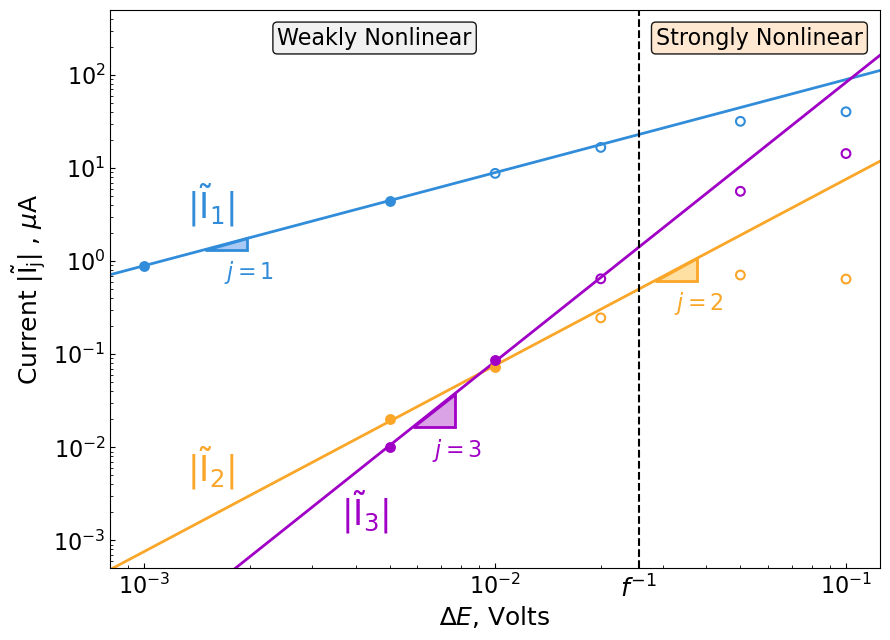

In [21]:
plot_filled_pair(df1,3,[(1,2),(2,3),(2,3)],1)

## Run 2

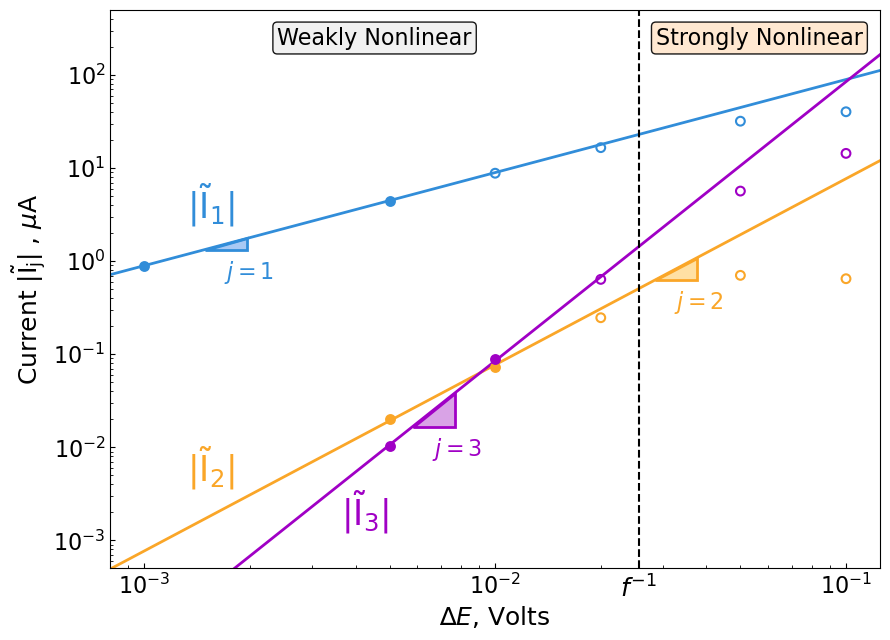

In [22]:
plot_filled_pair(df2,3,[(1,2),(2,3),(2,3)],2)